# 📧 Spam Email Detection Using Text Mining and Machine Learning

This notebook walks through a complete end-to-end pipeline for spam detection:
- Data exploration and visualization
- Text preprocessing with NLTK
- TF-IDF feature engineering
- Training and evaluating 3 ML models
- Saving the best model for deployment

## Step 1 – Import Necessary Libraries

In [1]:
# ── Standard libraries ──────────────────────────────────────────────────────
import os
import re
import string
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')

# ── NLP ──────────────────────────────────────────────────────────────────────
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Download required NLTK data (runs once)
for resource in ['punkt', 'stopwords', 'punkt_tab']:
    nltk.download(resource, quiet=True)

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

# ── Model persistence ─────────────────────────────────────────────────────────
import joblib

print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


## Step 2 – Load Dataset

In [2]:
# ── Locate CSV file inside the 'dataset' folder ──────────────────────────────
DATASET_FOLDER = 'dataset'

# Pick the first CSV found in the folder (supports any filename)
csv_files = [f for f in os.listdir(DATASET_FOLDER) if f.endswith('.csv')]
if not csv_files:
    raise FileNotFoundError(
        f"No CSV file found inside '{DATASET_FOLDER}/' folder. "
        "Please place your dataset CSV there."
    )

dataset_path = os.path.join(DATASET_FOLDER, csv_files[0])
print(f'Loading dataset: {dataset_path}')

df = pd.read_csv(dataset_path)

# ── Normalise column names (lowercase, strip whitespace) ─────────────────────
df.columns = df.columns.str.strip().str.lower()

# Rename to standard names if needed
if 'label' not in df.columns or 'text' not in df.columns:
    # Try common alternatives
    rename_map = {}
    for col in df.columns:
        if col in ('category', 'class', 'type', 'spam'):
            rename_map[col] = 'label'
        elif col in ('message', 'email', 'body', 'content', 'mail'):
            rename_map[col] = 'text'
    df.rename(columns=rename_map, inplace=True)

# Keep only the two required columns
df = df[['label', 'text']].copy()

# Drop rows with missing values
initial_len = len(df)
df.dropna(inplace=True)
print(f'Dropped {initial_len - len(df)} rows with missing values.')

# Reset index
df.reset_index(drop=True, inplace=True)

print(f'\n✅ Dataset loaded. Shape: {df.shape}')
df.head()

Loading dataset: dataset\spam_Emails_data.csv
Dropped 2 rows with missing values.

✅ Dataset loaded. Shape: (193850, 2)


,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
1,Ham,got ice thought look az original message ice o...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...
3,Spam,start increasing your odds of success & live s...
4,Ham,author jra date escapenumber escapenumber esca...


## Step 3 – Data Exploration

In [3]:
# ── Basic info ───────────────────────────────────────────────────────────────
print('=' * 50)
print('DATASET OVERVIEW')
print('=' * 50)
print(f'Shape   : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Columns : {list(df.columns)}')
print(f'\nData Types:\n{df.dtypes}')
print(f'\nNull Values:\n{df.isnull().sum()}')

DATASET OVERVIEW
Shape   : 193,850 rows × 2 columns
Columns : ['label', 'text']

Data Types:
label    object
text     object
dtype: object

Null Values:
label    0
text     0
dtype: int64


In [4]:
# ── Sample rows ──────────────────────────────────────────────────────────────
print('\nSample rows (Ham):')
display(df[df['label'].str.lower() == 'ham'].head(2))

print('\nSample rows (Spam):')
display(df[df['label'].str.lower() == 'spam'].head(2))


Sample rows (Ham):


,label,text
1,Ham,got ice thought look az original message ice o...
4,Ham,author jra date escapenumber escapenumber esca...



Sample rows (Spam):


,label,text
0,Spam,viiiiiiagraaaa\nonly for the ones that want to...
2,Spam,yo ur wom an ne eds an escapenumber in ch ma n...



Class Distribution:
  Ham   : 102,159  (52.7%)
  Spam  :  91,691  (47.3%)


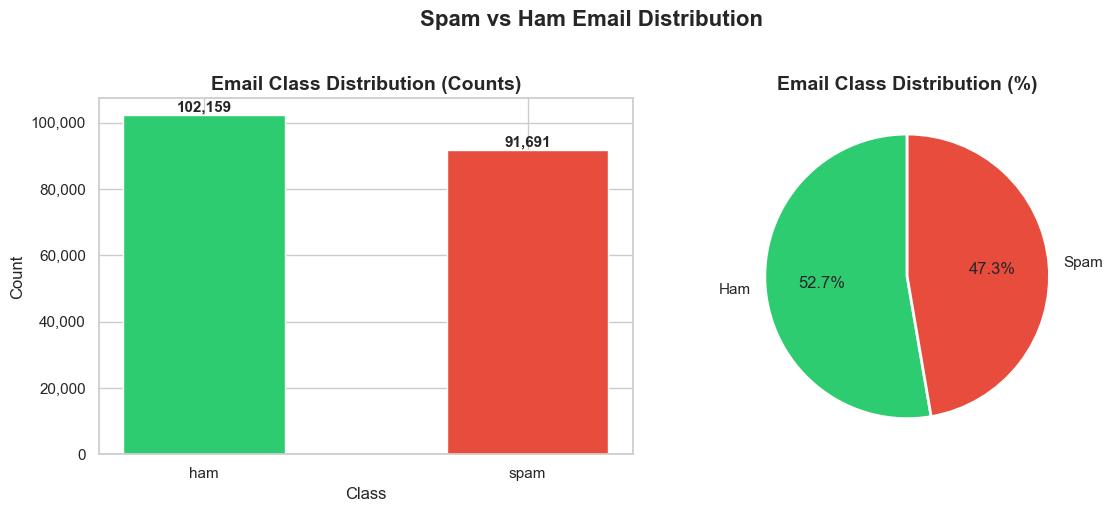

Plot saved as class_distribution.png


In [5]:
# ── Class distribution ───────────────────────────────────────────────────────
# Standardise label casing
df['label'] = df['label'].str.strip().str.lower()

class_counts = df['label'].value_counts()
class_pct    = df['label'].value_counts(normalize=True) * 100

print('\nClass Distribution:')
for label in class_counts.index:
    print(f'  {label.capitalize():6s}: {class_counts[label]:>7,}  ({class_pct[label]:.1f}%)')

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

colors = ['#2ecc71', '#e74c3c']   # green = ham, red = spam

# Count bar
bars = axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Email Class Distribution (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, val in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Percentage pie
axes[1].pie(class_pct.values, labels=[l.capitalize() for l in class_pct.index],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Email Class Distribution (%)', fontsize=14, fontweight='bold')

plt.suptitle('Spam vs Ham Email Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as class_distribution.png')

Text Length Statistics by Class:


,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,102159.0,2169.7,36562.7,1.0,417.0,950.0,1968.0,11510306.0
spam,91691.0,1415.1,2368.0,1.0,309.0,675.0,1570.0,144087.0


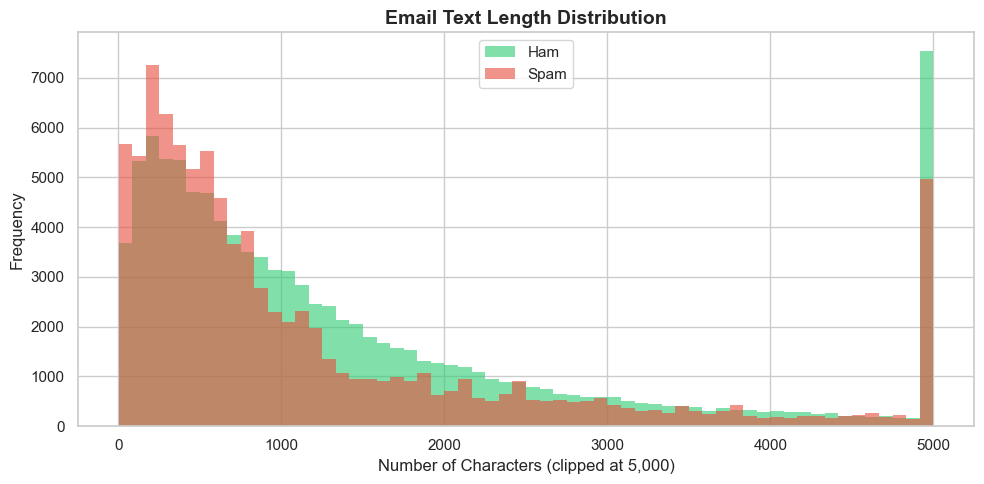

In [6]:
# ── Text length analysis ─────────────────────────────────────────────────────
df['text_length'] = df['text'].astype(str).apply(len)

print('Text Length Statistics by Class:')
display(df.groupby('label')['text_length'].describe().round(1))

fig, ax = plt.subplots(figsize=(10, 5))
for label, color in zip(['ham', 'spam'], colors):
    subset = df[df['label'] == label]['text_length']
    ax.hist(subset.clip(upper=5000), bins=60, alpha=0.6,
            label=label.capitalize(), color=color, edgecolor='none')
ax.set_title('Email Text Length Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Characters (clipped at 5,000)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 – Data Preprocessing

In [7]:
# ── Preprocessing pipeline ───────────────────────────────────────────────────
STOPWORDS = set(stopwords.words('english'))
stemmer   = PorterStemmer()

def preprocess_text(text: str) -> str:
    """
    Full preprocessing pipeline:
      1. Convert to string and lowercase
      2. Remove URLs
      3. Remove email addresses
      4. Remove punctuation and digits
      5. Tokenise
      6. Remove stopwords
      7. Stem each token
      8. Re-join tokens
    """
    # 1. Lowercase
    text = str(text).lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)

    # 3. Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # 4. Remove punctuation & digits
    text = re.sub(r'[^a-z\s]', '', text)

    # 5. Tokenise
    tokens = word_tokenize(text)

    # 6. Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]

    # 7. Stem
    tokens = [stemmer.stem(t) for t in tokens]

    # 8. Rejoin
    return ' '.join(tokens)


print('Preprocessing emails …  (this may take a few minutes on large datasets)')
df['clean_text'] = df['text'].apply(preprocess_text)
print(f'✅ Preprocessing complete.')

# Preview
print('\nOriginal vs Clean (first spam):')
sample = df[df['label'] == 'spam'].iloc[0]
print(f'  ORIGINAL : {sample["text"][:200]}')
print(f'  CLEAN    : {sample["clean_text"][:200]}')

Preprocessing emails …  (this may take a few minutes on large datasets)
✅ Preprocessing complete.

Original vs Clean (first spam):
  ORIGINAL : viiiiiiagraaaa
only for the ones that want to make her scream .
prodigy scrawny crow define upgrade spongy balboa dither moiseyev schumann variegate ponce bernie cox angeles impassive circulate impend
  CLEAN    : viiiiiiagraaaa one want make scream prodigi scrawni crow defin upgrad spongi balboa dither moiseyev schumann varieg ponc berni cox angel impass circul impend miscellani chalkboard whizz pend armenian 


## Step 5 – Feature Engineering (TF-IDF)

In [8]:
# ── Encode labels ────────────────────────────────────────────────────────────
# spam → 1,  ham → 0
df['label_enc'] = df['label'].map({'spam': 1, 'ham': 0})

# Drop any rows where mapping failed (unexpected label values)
df.dropna(subset=['label_enc'], inplace=True)
df['label_enc'] = df['label_enc'].astype(int)

X_raw = df['clean_text'].values
y     = df['label_enc'].values

print(f'Features shape : {X_raw.shape}')
print(f'Label distribution (after encoding):')
print(f'  Ham  (0): {(y == 0).sum():,}')
print(f'  Spam (1): {(y == 1).sum():,}')

Features shape : (193850,)
Label distribution (after encoding):
  Ham  (0): 102,159
  Spam (1): 91,691


In [9]:
# ── TF-IDF Vectoriser ────────────────────────────────────────────────────────
tfidf = TfidfVectorizer(
    max_features=50_000,   # top 50k tokens by frequency
    ngram_range=(1, 2),    # unigrams + bigrams
    sublinear_tf=True,     # apply 1+log(tf) scaling
    min_df=2               # ignore terms appearing in <2 documents
)

X = tfidf.fit_transform(X_raw)

print(f'TF-IDF matrix shape : {X.shape}')
print(f'Number of features  : {len(tfidf.vocabulary_):,}')

# Save vectoriser now (fit on full data)
os.makedirs('models', exist_ok=True)
joblib.dump(tfidf, 'models/tfidf_vectorizer.pkl')
print('\n✅ TF-IDF vectoriser saved → models/tfidf_vectorizer.pkl')

TF-IDF matrix shape : (193850, 50000)
Number of features  : 50,000

✅ TF-IDF vectoriser saved → models/tfidf_vectorizer.pkl


## Step 6 – Train / Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserve class balance
)

print('Train/Test Split (80/20 stratified):')
print(f'  Training samples : {X_train.shape[0]:,}')
print(f'  Testing  samples : {X_test.shape[0]:,}')

print(f'\nTrain spam ratio : {y_train.mean():.3f}')
print(f'Test  spam ratio : {y_test.mean():.3f}')

Train/Test Split (80/20 stratified):
  Training samples : 155,080
  Testing  samples : 38,770

Train spam ratio : 0.473
Test  spam ratio : 0.473


## Step 7 – Model Training

In [11]:
import time

models = {
    'Naive Bayes'          : MultinomialNB(alpha=0.1),
    'Logistic Regression'  : LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42),
    'SVM (LinearSVC)'      : LinearSVC(C=1.0, max_iter=2000, random_state=42)
}

trained_models = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - start
    trained_models[name] = model
    print(f'  ✅ {name:<25} trained in {elapsed:.1f}s')

print('\n✅ All models trained.')

  ✅ Naive Bayes               trained in 0.1s
  ✅ Logistic Regression       trained in 0.8s
  ✅ SVM (LinearSVC)           trained in 5.0s

✅ All models trained.


## Step 8 – Model Evaluation

In [12]:
def evaluate_model(name, model, X_test, y_test):
    """Compute all evaluation metrics and return as a dict."""
    y_pred = model.predict(X_test)

    # Standard metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Derived rates
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0   # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0   # False Negative Rate
    sdr = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Spam Detection Rate (= Recall)

    return {
        'Model'            : name,
        'Accuracy'         : acc,
        'Precision'        : prec,
        'Recall'           : rec,
        'F1-Score'         : f1,
        'FPR'              : fpr,
        'FNR'              : fnr,
        'Spam Detect Rate' : sdr,
        'TN'               : tn,
        'FP'               : fp,
        'FN'               : fn,
        'TP'               : tp,
        'y_pred'           : y_pred,
        'cm'               : cm
    }


results = {}
for name, model in trained_models.items():
    results[name] = evaluate_model(name, model, X_test, y_test)

print('✅ Evaluation complete.')

✅ Evaluation complete.


In [13]:
# ── Print detailed reports ───────────────────────────────────────────────────
for name, res in results.items():
    print('\n' + '='*60)
    print(f'  {name}')
    print('='*60)
    print(f"  Accuracy          : {res['Accuracy']:.4f}")
    print(f"  Precision         : {res['Precision']:.4f}")
    print(f"  Recall            : {res['Recall']:.4f}")
    print(f"  F1-Score          : {res['F1-Score']:.4f}")
    print(f"  False Positive Rate: {res['FPR']:.4f}")
    print(f"  False Negative Rate: {res['FNR']:.4f}")
    print(f"  Spam Detection Rate: {res['Spam Detect Rate']:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"    TN={res['TN']:>6,}   FP={res['FP']:>6,}")
    print(f"    FN={res['FN']:>6,}   TP={res['TP']:>6,}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, res['y_pred'],
                                target_names=['Ham', 'Spam']))


  Naive Bayes
  Accuracy          : 0.9519
  Precision         : 0.9797
  Recall            : 0.9174
  F1-Score          : 0.9475
  False Positive Rate: 0.0171
  False Negative Rate: 0.0826
  Spam Detection Rate: 0.9174

  Confusion Matrix:
    TN=20,083   FP=   349
    FN= 1,514   TP=16,824

  Classification Report:
              precision    recall  f1-score   support

         Ham       0.93      0.98      0.96     20432
        Spam       0.98      0.92      0.95     18338

    accuracy                           0.95     38770
   macro avg       0.95      0.95      0.95     38770
weighted avg       0.95      0.95      0.95     38770


  Logistic Regression
  Accuracy          : 0.9793
  Precision         : 0.9717
  Recall            : 0.9850
  F1-Score          : 0.9783
  False Positive Rate: 0.0257
  False Negative Rate: 0.0150
  Spam Detection Rate: 0.9850

  Confusion Matrix:
    TN=19,906   FP=   526
    FN=   275   TP=18,063

  Classification Report:
              precision  

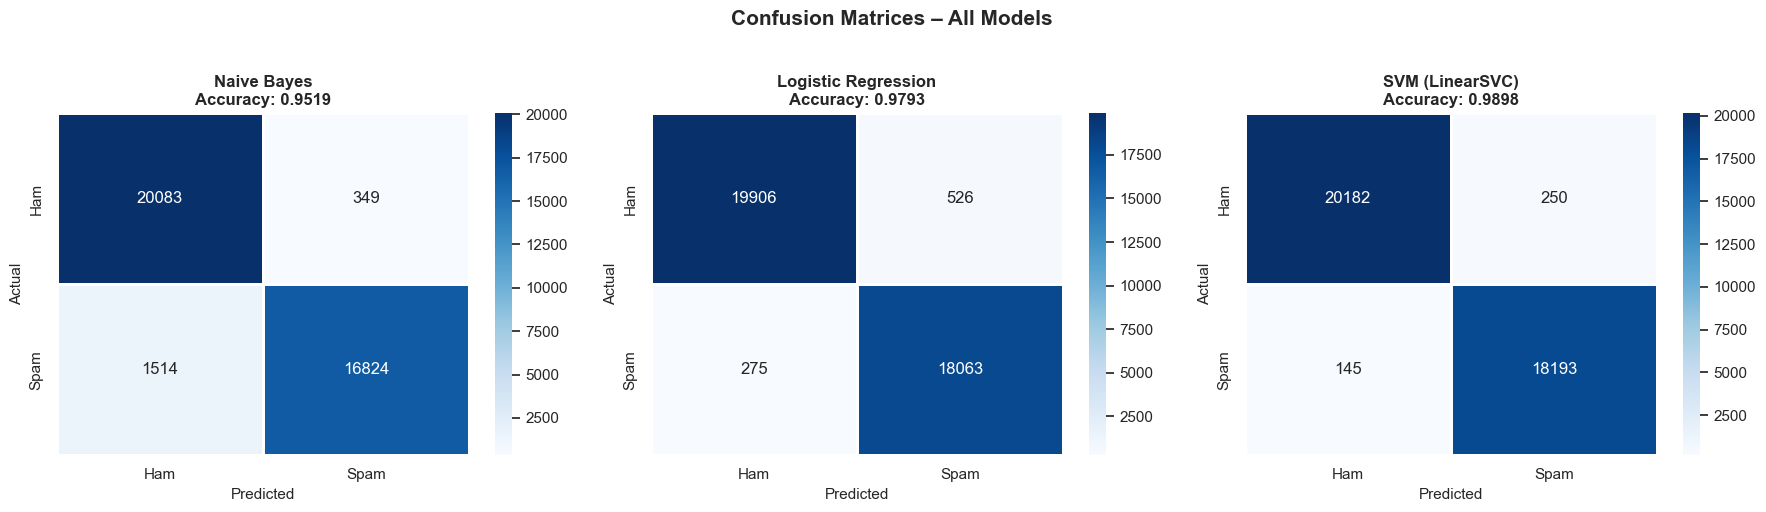

Plot saved as confusion_matrices.png


In [14]:
# ── Visualise confusion matrices ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(
        res['cm'], annot=True, fmt='d', cmap='Blues',
        xticklabels=['Ham', 'Spam'],
        yticklabels=['Ham', 'Spam'],
        ax=ax, linewidths=1, linecolor='white'
    )
    ax.set_title(f'{name}\nAccuracy: {res["Accuracy"]:.4f}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)

plt.suptitle('Confusion Matrices – All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as confusion_matrices.png')

## Step 9 – Compare All Models

In [15]:
# ── Comparison table ─────────────────────────────────────────────────────────
metrics_cols = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score',
                'FPR', 'FNR', 'Spam Detect Rate']

comparison_df = pd.DataFrame(
    [{k: v for k, v in res.items() if k in metrics_cols}
     for res in results.values()]
).set_index('Model')

print('\n📊 Model Comparison Table:')
display(comparison_df.style
        .format('{:.4f}')
        .highlight_max(subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Spam Detect Rate'],
                       color='#d4edda')
        .highlight_min(subset=['FPR', 'FNR'],
                       color='#d4edda')
        .set_caption('Green = Best value in each column'))


📊 Model Comparison Table:


,Accuracy,Precision,Recall,F1-Score,FPR,FNR,Spam Detect Rate
Model,,,,,,,
Naive Bayes,0.9519,0.9797,0.9174,0.9475,0.0171,0.0826,0.9174
Logistic Regression,0.9793,0.9717,0.9850,0.9783,0.0257,0.0150,0.9850
SVM (LinearSVC),0.9898,0.9864,0.9921,0.9893,0.0122,0.0079,0.9921


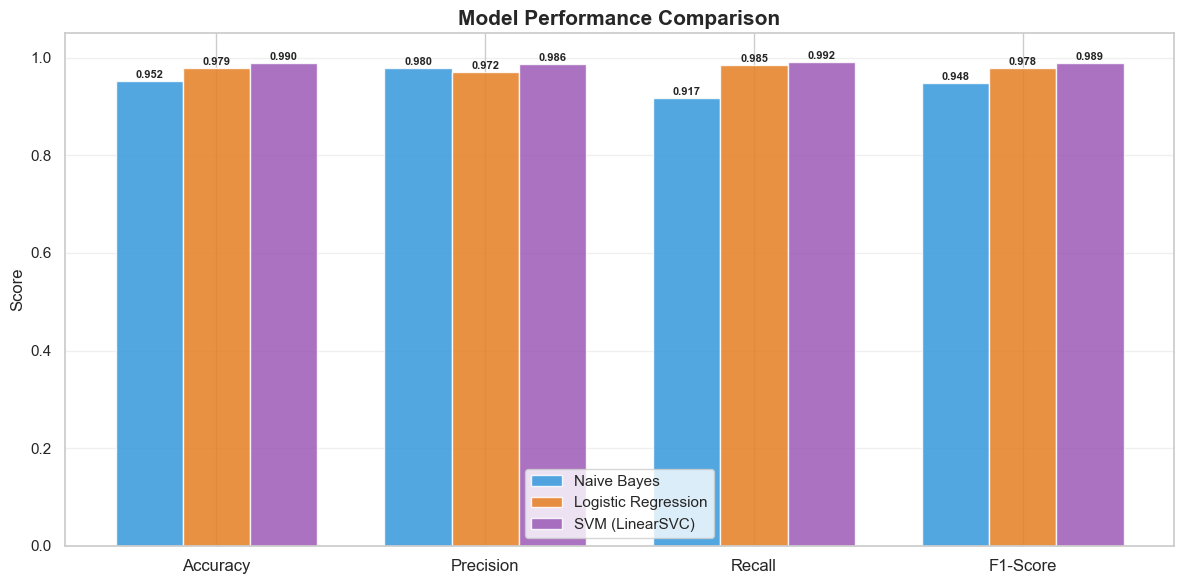

Plot saved as model_comparison.png


In [16]:
# ── Bar chart comparison ──────────────────────────────────────────────────────
plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(plot_metrics))
width = 0.25
model_names = list(comparison_df.index)
bar_colors  = ['#3498db', '#e67e22', '#9b59b6']

fig, ax = plt.subplots(figsize=(12, 6))

for i, (model_name, color) in enumerate(zip(model_names, bar_colors)):
    vals = [comparison_df.loc[model_name, m] for m in plot_metrics]
    bars = ax.bar(x + i * width, vals, width, label=model_name,
                  color=color, edgecolor='white', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Model Performance Comparison', fontsize=15, fontweight='bold')
ax.set_ylabel('Score', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(plot_metrics, fontsize=12)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as model_comparison.png')

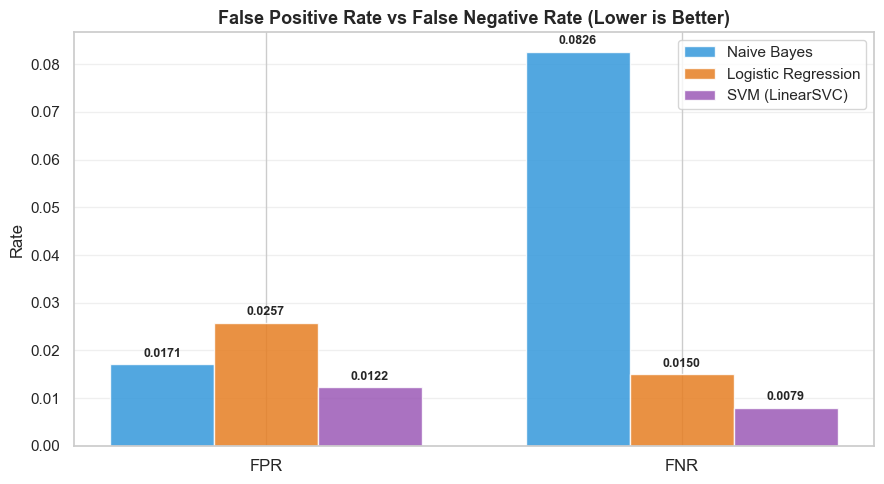

In [17]:
# ── FPR / FNR comparison ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

rate_metrics = ['FPR', 'FNR']
x2 = np.arange(len(rate_metrics))

for i, (model_name, color) in enumerate(zip(model_names, bar_colors)):
    vals = [comparison_df.loc[model_name, m] for m in rate_metrics]
    bars = ax.bar(x2 + i * width, vals, width, label=model_name,
                  color=color, edgecolor='white', alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_title('False Positive Rate vs False Negative Rate (Lower is Better)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Rate', fontsize=12)
ax.set_xticks(x2 + width)
ax.set_xticklabels(rate_metrics, fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('fpr_fnr_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Identify best model by F1-Score ──────────────────────────────────────────
best_model_name = comparison_df['F1-Score'].idxmax()
best_model      = trained_models[best_model_name]
best_metrics    = comparison_df.loc[best_model_name]

print('\n' + '='*60)
print(f'  🏆  BEST MODEL: {best_model_name}')
print('='*60)
for metric, val in best_metrics.items():
    print(f'  {metric:<20}: {val:.4f}')

print(f'\nReasoning: Selected by highest F1-Score, which balances')
print(f'precision and recall – critical for spam detection.')


  🏆  BEST MODEL: SVM (LinearSVC)
  Accuracy            : 0.9898
  Precision           : 0.9864
  Recall              : 0.9921
  F1-Score            : 0.9893
  FPR                 : 0.0122
  FNR                 : 0.0079
  Spam Detect Rate    : 0.9921

Reasoning: Selected by highest F1-Score, which balances
precision and recall – critical for spam detection.


## Step 10 – Save Best Model & Vectoriser

In [19]:
# ── Save best model ──────────────────────────────────────────────────────────
model_path     = 'models/best_model.pkl'
model_name_path = 'models/best_model_name.txt'

joblib.dump(best_model, model_path)

# Also save the model name so the Streamlit app can display it
with open(model_name_path, 'w') as f:
    f.write(best_model_name)

print(f'✅ Best model saved → {model_path}')
print(f'✅ Model name saved → {model_name_path}')
print(f'✅ TF-IDF vectoriser already saved → models/tfidf_vectorizer.pkl')

# Verify files exist
print('\nSaved files:')
for fname in os.listdir('models'):
    size = os.path.getsize(os.path.join('models', fname))
    print(f'  models/{fname}  ({size/1024:.1f} KB)')

✅ Best model saved → models/best_model.pkl
✅ Model name saved → models/best_model_name.txt
✅ TF-IDF vectoriser already saved → models/tfidf_vectorizer.pkl

Saved files:
  models/best_model.pkl  (391.3 KB)
  models/best_model_name.txt  (0.0 KB)
  models/tfidf_vectorizer.pkl  (1978.8 KB)


In [20]:
# ── Sanity check: reload and predict ────────────────────────────────────────
loaded_model  = joblib.load('models/best_model.pkl')
loaded_tfidf  = joblib.load('models/tfidf_vectorizer.pkl')

test_emails = [
    "Congratulations! You won a FREE iPhone. Click now to claim your prize!",
    "Hi John, please find the meeting notes attached. See you tomorrow."
]

print('🔍 Sanity-check predictions on 2 sample emails:')
for email in test_emails:
    cleaned   = preprocess_text(email)
    vectorised = loaded_tfidf.transform([cleaned])
    pred       = loaded_model.predict(vectorised)[0]
    label      = '🔴 SPAM' if pred == 1 else '🟢 HAM'
    print(f'\n  Email  : {email[:80]}…')
    print(f'  Result : {label}')

print('\n✅ Pipeline verified. Ready for deployment!')

🔍 Sanity-check predictions on 2 sample emails:

  Email  : Congratulations! You won a FREE iPhone. Click now to claim your prize!…
  Result : 🔴 SPAM

  Email  : Hi John, please find the meeting notes attached. See you tomorrow.…
  Result : 🟢 HAM

✅ Pipeline verified. Ready for deployment!


---
## 📋 Summary

| Step | What we did |
|------|-------------|
| 1 | Imported all required libraries |
| 2 | Loaded dataset from the `dataset/` folder |
| 3 | Explored data: shape, class balance, text length |
| 4 | Preprocessed text: lowercase, remove punctuation, remove URLs, remove stopwords, stemming |
| 5 | Built TF-IDF feature matrix (unigrams + bigrams, top 50k features) |
| 6 | Split 80/20 with stratification |
| 7 | Trained Naïve Bayes, Logistic Regression, and LinearSVC |
| 8 | Evaluated all models: Accuracy, Precision, Recall, F1, FPR, FNR, Spam Detection Rate |
| 9 | Compared models visually; best model identified by highest F1-Score |
| 10 | Saved best model + TF-IDF vectoriser to `models/` folder |

```